# **Step 1: Import Libraries**

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder,RobustScaler
from sklearn.model_selection import train_test_split,cross_val_score


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score as r2_metric, mean_absolute_error as mae_metric




import warnings
warnings.filterwarnings("ignore")

#  **Step 2 : Load Dataset**

In [43]:
df=pd.read_csv("House_Rent_Dataset.csv")

In [44]:
from google.colab import sheets
from google.colab import auth

# Authenticate user to ensure proper credentials
auth.authenticate_user()

sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1AfkgGARaOCXEgEwkQvVQzbLKgZmpnR_u4fbltQrV7_E/edit#gid=0


In [45]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


# **Step 3 : Eda**

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [47]:
df.shape

(4746, 12)

In [48]:
df. describe ()


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [49]:
df.describe(include='object')

,Posted On,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Point of Contact
count,4746,4746,4746,4746,4746,4746,4746,4746
unique,81,480,3,2235,6,3,3,3
top,2022-07-06,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,Contact Owner
freq,311,379,2446,37,972,2251,3444,3216


In [50]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
print("\n. Unique Values Per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} ")




. Unique Values Per Column:
Posted On: 81 
BHK: 6 
Rent: 243 
Size: 615 
Floor: 480 
Area Type: 3 
Area Locality: 2235 
City: 6 
Furnishing Status: 3 
Tenant Preferred: 3 
Bathroom: 8 
Point of Contact: 3 


In [53]:
print(df["City"].value_counts())

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64


In [54]:
print(" Furnishing Status Distribution:")
df["Furnishing Status"].value_counts()

 Furnishing Status Distribution:


,count
Furnishing Status,
Semi-Furnished,2251
Unfurnished,1815
Furnished,680


In [55]:
df['Rent'].describe()

,Rent
count,4.746000e+03
mean,3.499345e+04
std,7.810641e+04
min,1.200000e+03
25%,1.000000e+04
50%,1.600000e+04
75%,3.300000e+04
max,3.500000e+06


In [56]:
df['BHK'].value_counts()

,count
BHK,
2,2265
1,1167
3,1098
4,189
5,19
6,8


In [57]:
df["Bathroom"].value_counts()

,count
Bathroom,
2,2291
1,1474
3,749
4,156
5,60
6,12
7,3
10,1


Text(0, 0.5, 'Median Rent ')

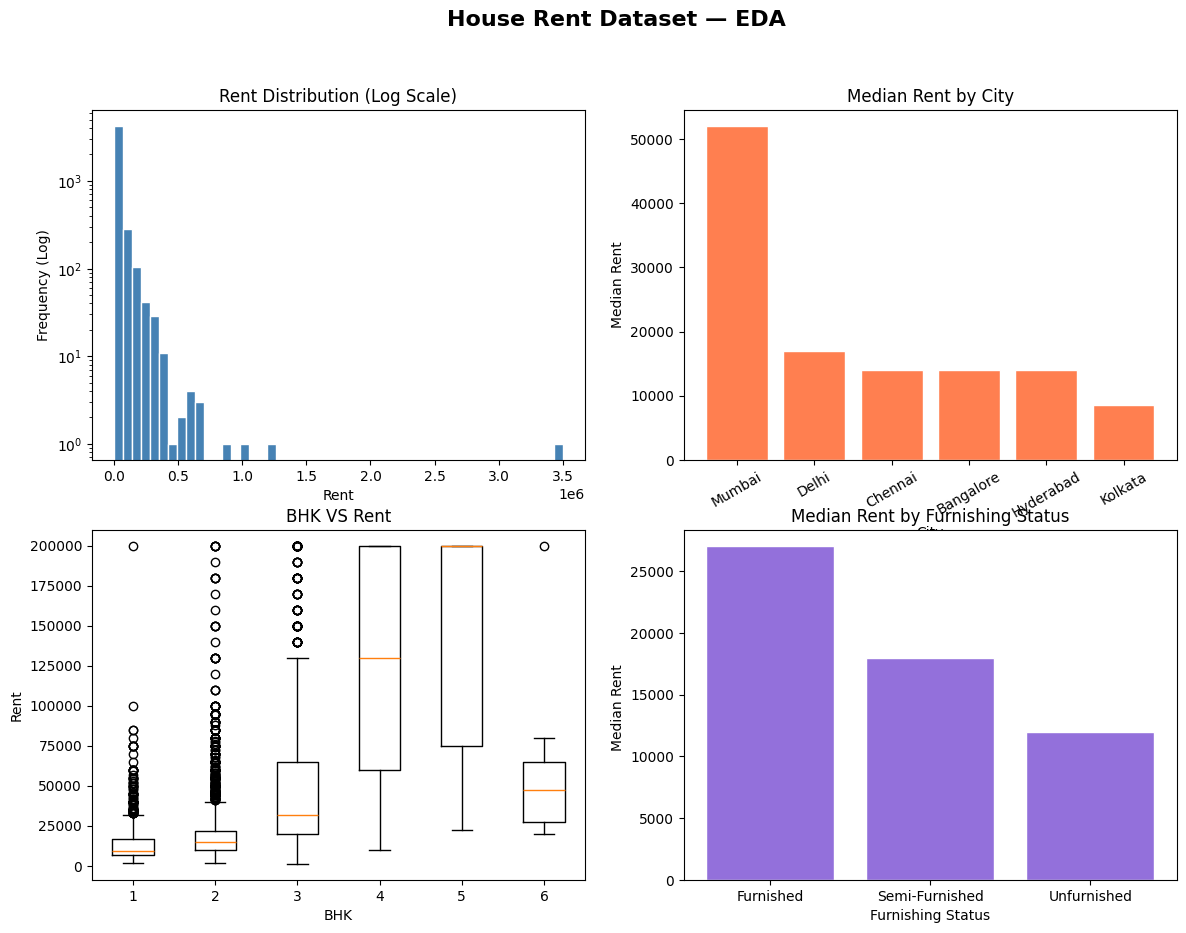

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("House Rent Dataset — EDA", fontsize=16, fontweight="bold")

# 1. Rent Distribution (Log Scale Applied Here)
axes[0, 0].hist(df["Rent"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_yscale('log')  # <--- Yeh line aapka kaam karegi!
axes[0, 0].set_title("Rent Distribution (Log Scale)")
axes[0, 0].set_xlabel("Rent")
axes[0, 0].set_ylabel("Frequency (Log)")

# 2. Median Rent by City
city_rent = df.groupby("City")["Rent"].median().sort_values(ascending=False)
axes[0, 1].bar(city_rent.index, city_rent.values, color="coral", edgecolor="white")
axes[0, 1].set_title("Median Rent by City")
axes[0, 1].set_xlabel("City")
axes[0, 1].set_ylabel("Median Rent")
axes[0, 1].tick_params(axis="x", rotation=30)

# 3. BHK vs Rent
bhk_list = sorted(df["BHK"].unique())

rent_data = []

for b in bhk_list:
    rents = df[df["BHK"] == b]["Rent"]
    rents = rents.clip(upper=200000)
    rent_data.append(rents)

axes[1,0].boxplot(rent_data, labels=bhk_list)
axes[1,0].set_title("BHK VS Rent")
axes[1,0].set_xlabel("BHK")
axes[1,0].set_ylabel("Rent")


# 4. Furnishing Status vs Rent
furn_rent = df.groupby("Furnishing Status")["Rent"].median()
axes[1, 1].bar(furn_rent.index, furn_rent.values, color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Median Rent by Furnishing Status")
axes[1, 1].set_xlabel("Furnishing Status")
axes[1, 1].set_ylabel("Median Rent ")






# **Step 4 : Data Cleaning and Preprocessing**

In [59]:
df_clean=df.copy()
target    = "Rent"
features_to_use=['BHK','Size','Bathroom',"Area Type",'City','Furnishing Status']
print(f" Features selected for modeling : {features_to_use}")
print(f"   Target           : {target}")

 Features selected for modeling : ['BHK', 'Size', 'Bathroom', 'Area Type', 'City', 'Furnishing Status']
   Target           : Rent


In [60]:
df_clean['Rent'] = df['Rent'] # Reset Rent column to original values to prevent double log-transformation
print(f"df_clean['Rent'] min: {df_clean['Rent'].min():,.0f}, max: {df_clean['Rent'].max():,.0f}")

df_clean['Rent'] min: 1,200, max: 3,500,000


In [61]:
# 4c. Outlier Handling — IQR Method (NAYA)
Q1  = df_clean['Rent'].quantile(0.25)
Q3  = df_clean['Rent'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print(f"Upper Limit : ₹{upper_limit:,.0f}")
print(f"Outliers    : {(df_clean['Rent'] > upper_limit).sum()} rows")

# Cap karo — delete nahi!
df_clean['Rent'] = df_clean['Rent'].clip(upper=upper_limit)

# 4d. Log Transformation (pehle wala 4c — ab 4d ban gaya)
print("Log Transformation applied...")

# 4e. Encode Categorical (pehle wala 4d — ab 4e ban gaya)

Upper Limit : ₹67,500
Outliers    : 520 rows
Log Transformation applied...


In [62]:
before_max = df_clean[target].max()
#


In [63]:
label_encoders = {}
categorical_cols = ["Area Type", "City", "Furnishing Status"]

print(f"\n Encoding categorical columns:")

for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f"   {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}\n")

print(f"\n Final modeling dataframe shape: {df_clean.shape}")


 Encoding categorical columns:
   Area Type: {'Built Area': np.int64(0), 'Carpet Area': np.int64(1), 'Super Area': np.int64(2)}

   City: {'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Hyderabad': np.int64(3), 'Kolkata': np.int64(4), 'Mumbai': np.int64(5)}

   Furnishing Status: {'Furnished': np.int64(0), 'Semi-Furnished': np.int64(1), 'Unfurnished': np.int64(2)}


 Final modeling dataframe shape: (4746, 12)


# **Step 5 : Correlation**


Correlation with Rent:
Rent                 1.000000
Bathroom             0.640574
BHK                  0.541739
Size                 0.511493
City                 0.390180
Furnishing Status   -0.265506
Area Type           -0.397668

 Heatmap saved → correlation_heatmap.png


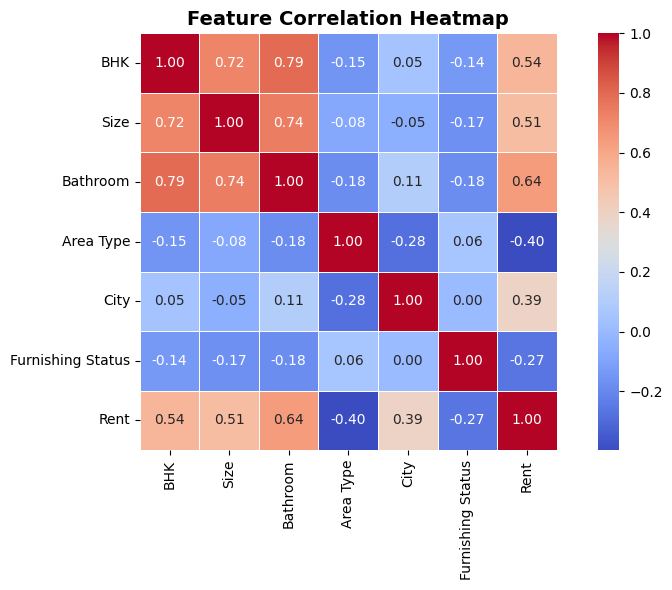

In [64]:
correlation_col=features_to_use+[target]
corr=df_clean[correlation_col].corr()

print("\nCorrelation with Rent:")
print(corr[target].sort_values(ascending=False).to_string())

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()


print("\n Heatmap saved → correlation_heatmap.png")

# **Step 6 : Train_Test_Split**

In [65]:
x=df_clean[features_to_use]
y = np.log1p(df_clean[target]) # Ensuring y is log-transformed using df_clean

print(f"x shape: {x.shape}\ny shape: {y.shape} ")

x shape: (4746, 6)
y shape: (4746,) 


In [66]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(f" Training samples : {x_train.shape[0]}")
print(f" Testing samples  : {x_test.shape[0]}")

 Training samples : 3796
 Testing samples  : 950


In [67]:
# Define y_test_orig globally for consistent use across model evaluation cells
y_test_orig = np.expm1(np.clip(y_test, 0, 20))
print(f"y_test_orig min: {y_test_orig.min():,.0f}, max: {y_test_orig.max():,.0f}")

y_test_orig min: 1,800, max: 67,500


# **Step 7: Scaling(Robust_Scaler)**

In [68]:
scaler=RobustScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# **Step  8: Model Training and Evalutaion**

In [69]:
models = {
    'Linear Regression'          : LinearRegression(),
    'Decision Tree Regressor'    : DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    x_tr = x_train_scaled if name == 'Linear Regression' else x_train
    x_te = x_test_scaled  if name == 'Linear Regression' else x_test

    model.fit(x_tr, y_train)
    y_pred_log = model.predict(x_te)


    y_pred_log_clipped = np.clip(y_pred_log, 0, 20)
    y_test_log_clipped = np.clip(y_test,     0, 20)

    # Convert back to original scale
    y_pred_original = np.expm1(y_pred_log_clipped)
    y_test_original = np.expm1(y_test_log_clipped)

    mae  = mae_metric(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    r2   = r2_metric(y_test_original, y_pred_original)

    results[name] = {
        "MAE"      : mae,
        "RMSE"     : rmse,
        "R2"       : r2,
        "model"    : model,
        "preds"    : y_pred_original,    # original  scale
        "preds_log": y_pred_log_clipped  # log scale
    }

    print(f"\n {name}")
    print(f"   R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"   MAE  : {mae:,.0f}  (avg prediction error)")
    print(f"   RMSE : {rmse:,.0f}")


 Linear Regression
   R²   : 0.3393  (33.9% variance explained)
   MAE  : 9,304  (avg prediction error)
   RMSE : 16,004

 Decision Tree Regressor
   R²   : 0.7348  (73.5% variance explained)
   MAE  : 6,207  (avg prediction error)
   RMSE : 10,139

 Random Forest Regressor
   R²   : 0.8163  (81.6% variance explained)
   MAE  : 5,432  (avg prediction error)
   RMSE : 8,439

 Gradient Boosting Regressor
   R²   : 0.8313  (83.1% variance explained)
   MAE  : 5,357  (avg prediction error)
   RMSE : 8,088


In [77]:
# ─────────────────────────────────────────
# STEP 10 — XGBoost
# ─────────────────────────────────────────
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(x_train, y_train)

y_pred_log_xgb     = xgb_model.predict(x_test)
y_pred_clipped_xgb = np.clip(y_pred_log_xgb, 0, 20)
y_pred_orig_xgb    = np.expm1(y_pred_clipped_xgb)
y_test_orig        = np.expm1(np.clip(y_test, 0, 20))

r2_xgb  = r2_metric(y_test_orig, y_pred_orig_xgb)
mae_xgb = mae_metric(y_test_orig, y_pred_orig_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig_xgb))

print(" XGBoost Regressor")
print(f"   R²   : {r2_xgb:.4f}  ({r2_xgb*100:.1f}% variance explained)")
print(f"   MAE  : {mae_xgb:,.0f}")
print(f"   RMSE : {rmse_xgb:,.0f}")

# Results mein add karo
results['XGBoost Regressor'] = {
    "MAE"  : mae_xgb,
    "RMSE" : rmse_xgb,
    "R2"   : r2_xgb,
    "model": xgb_model,
    "preds": y_pred_orig_xgb
}

 XGBoost Regressor
   R²   : 0.7963  (79.6% variance explained)
   MAE  : 5,756
   RMSE : 8,885


In [71]:
# ─────────────────────────────────────────
# STEp— Hyperparameter Tuning
# ─────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 4, 5]
}

grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print(f"\n Best Parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")

# Best model se predict karo
best_tuned = grid_search.best_estimator_
y_pred_tuned = np.expm1(np.clip(best_tuned.predict(x_test), 0, 20))

r2_tuned  = r2_metric(y_test_orig, y_pred_tuned)
mae_tuned = mae_metric(y_test_orig, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_orig, y_pred_tuned))

print(f"\n Gradient Boosting (Tuned)")
print(f"   R²   : {r2_tuned:.4f}  ({r2_tuned*100:.1f}% variance explained)")
print(f"   MAE  : {mae_tuned:,.0f}")
print(f"   RMSE : {rmse_tuned:,.0f}")

# Results mein add karo
results['GB Tuned'] = {
    "MAE"  : mae_tuned,
    "RMSE" : rmse_tuned,
    "R2"   : r2_tuned,
    "model": best_tuned,
    "preds": y_pred_tuned
}

Fitting 5 folds for each of 27 candidates, totalling 135 fits

 Best Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best CV R²      : 0.7836

 Gradient Boosting (Tuned)
   R²   : 0.8361  (83.6% variance explained)
   MAE  : 5,305
   RMSE : 7,971


# **Step 9: Select Best Model**

In [72]:
comparison_df = pd.DataFrame({
    name: {"R2 Score": v["R2"], "MAE": v["MAE"], "RMSE": v["RMSE"]}
    for name, v in results.items()
}).T.sort_values("R2 Score", ascending=False)

display(comparison_df)

best_name = comparison_df.index[0]
best_r2   = comparison_df.iloc[0]["R2 Score"]
print(f"\nBest Model : {best_name}  (R² = {best_r2:.4f})")






,R2 Score,MAE,RMSE
GB Tuned,0.836086,5304.866946,7971.135757
Gradient Boosting Regressor,0.831257,5356.791879,8087.702440
Random Forest Regressor,0.816268,5431.827536,8439.261449
XGBoost Regressor,0.796328,5756.187365,8885.417265
Decision Tree Regressor,0.734806,6207.414444,10138.953876
Linear Regression,0.339290,9304.100448,16003.576353



Best Model : GB Tuned  (R² = 0.8361)


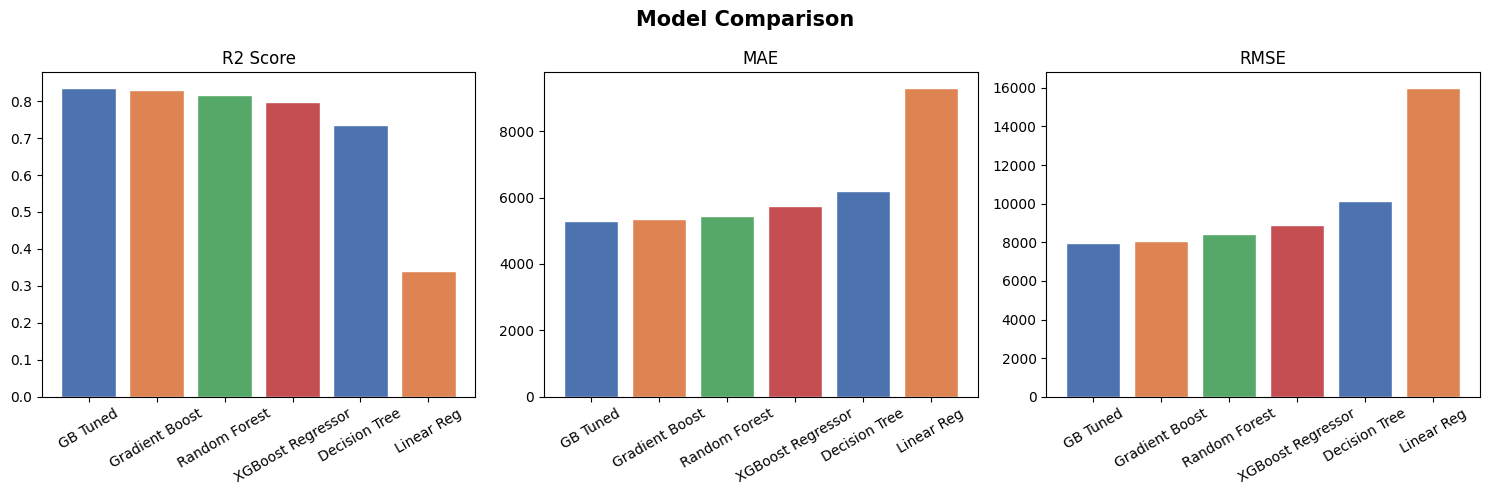

In [73]:
# Map long model names to shorter versions for plotting

name_map = {
    'Linear Regression': 'Linear Reg',
    'Decision Tree Regressor': 'Decision Tree',
    'Random Forest Regressor': 'Random Forest',
    'Gradient Boosting Regressor': 'Gradient Boost'
}
comparison_df_plot = comparison_df.rename(index=name_map)

# Comparison Chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison", fontsize=15, fontweight="bold")
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]



for ax, metric in zip(axes, ["R2 Score", "MAE", "RMSE"]):
    vals = comparison_df_plot[metric] # Use the DataFrame with shortened names
    ax.bar(vals.index, vals.values, color=colors, edgecolor="white")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=30) # Increased rotation to 45 degrees

plt.tight_layout()

# **Step 10: Scatter Graph**

 STEP 11: Actual vs Predicted — GB Tuned


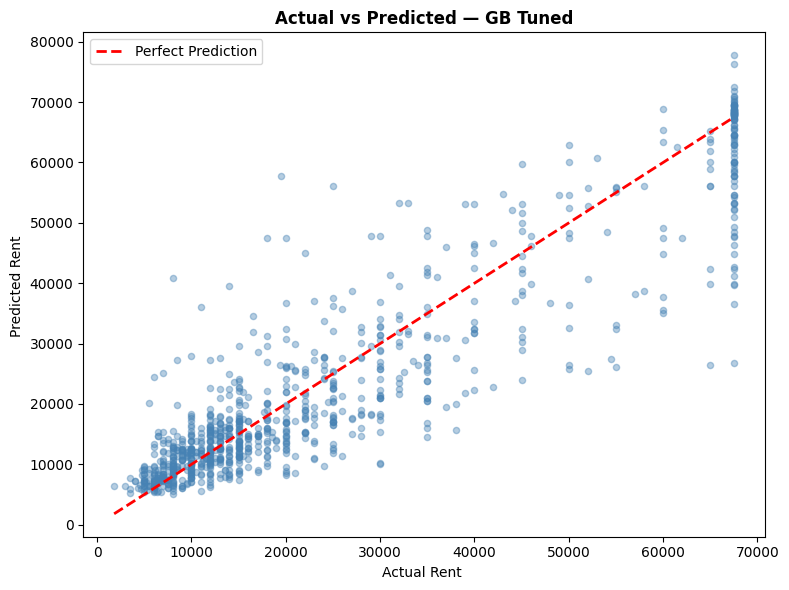

In [74]:
print(f" STEP 11: Actual vs Predicted — {best_name}")

best_preds = results[best_name]["preds"] # These are already in original scale

# Inverse transform y_test for plotting against original scale predictions
y_test_original_scale = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_original_scale, best_preds, alpha=0.4, color="steelblue", s=20)
plt.plot([y_test_original_scale.min(), y_test_original_scale.max()],
         [y_test_original_scale.min(), y_test_original_scale.max()],
         "r--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Rent ")
plt.ylabel("Predicted Rent ")
plt.title(f"Actual vs Predicted — {best_name}", fontweight="bold")
plt.legend()
plt.tight_layout()

# **Step 11: Feature Importance**

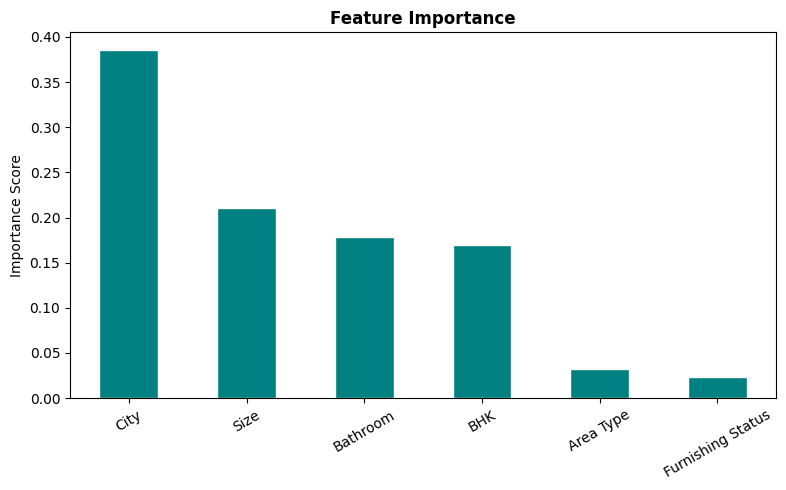

In [75]:
best_model = results[best_name]["model"]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=features_to_use)
    importances = importances.sort_values(ascending=False)



    plt.figure(figsize=(8, 5))
    importances.plot(kind="bar", color="teal", edgecolor="white")
    plt.title("Feature Importance", fontweight="bold")
    plt.ylabel("Importance Score")
    plt.xticks(rotation=30)
    plt.tight_layout()

# **Cross Validation**


In [76]:
from sklearn.model_selection import KFold

# Stable 5-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_tuned, x, y,
    cv=kf,
    scoring='r2'
)

print(f"CV Scores : {[round(s,4) for s in cv_scores]}")
print(f"Mean R²   : {cv_scores.mean():.4f}")
print(f"Std Dev   : {cv_scores.std():.4f}")

CV Scores : [np.float64(0.7925), np.float64(0.7743), np.float64(0.7899), np.float64(0.7952), np.float64(0.7784)]
Mean R²   : 0.7860
Std Dev   : 0.0082


In [80]:
# New house details
new_house = {
    "BHK"              : 2,
    "Size"             : 1000,
    "Area Type"        : "Super Area",
    "City"             : "Bangalore",
    "Furnishing Status": "Semi-Furnished",
    "Bathroom"         : 2,
}

print("\n   Input Details:")
for k, v in new_house.items():
    print(f"   {k:<20} : {v}")

# Encode categorical values using saved encoders
# Create a dictionary for the single sample with features in the correct order
sample_data = {
    "BHK"              : new_house["BHK"],
    "Size"             : new_house["Size"],
    "Bathroom"         : new_house["Bathroom"],
    "Area Type"        : label_encoders["Area Type"].transform([new_house["Area Type"]])[0],
    "City"             : label_encoders["City"].transform([new_house["City"]])[0],
    "Furnishing Status": label_encoders["Furnishing Status"].transform([new_house["Furnishing Status"]])[0],
}

# Create the DataFrame ensuring column order matches 'features_to_use'
sample = pd.DataFrame([sample_data], columns=features_to_use)

predicted_rent = np.expm1(best_model.predict(sample)[0])
print(f"\n    Predicted Rent : {predicted_rent:,.0f} / month")


   Input Details:
   BHK                  : 2
   Size                 : 1000
   Area Type            : Super Area
   City                 : Bangalore
   Furnishing Status    : Semi-Furnished
   Bathroom             : 2

    Predicted Rent : 14,759 / month
